# Ensemble Models - Custom (Iris)

- Author: Jaya Srinivas
- Date: 2026-07
- Dataset: Seaborn Iris
- Target: species

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Overview

This is a custom copy of the M5 Ensembles example, built on the **iris** dataset.
Iris is one of the easiest classification datasets there is: 3 flower species, 4 clean numeric measurements, no missing values, and the classes are naturally well separated.

We predict `species` (a discrete category), so this is a supervised classification problem. We fit one single decision tree and two ensembles (random forest, gradient boosting), then compare them on held-out test data.


## Section 0. Ensembles, Briefly

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Gradient boosting** - trees added one at a time, each correcting the previous trees' errors.

On an easy, well-separated dataset like iris, we expect all three models to score high. The interesting question is whether the ensembles' extra complexity earns anything at all here, or whether the simple tree already does the job.

## Section 1. Project Setup and Imports

In [9]:
# Section 1

import logging
from typing import Final

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Section 1b

LOG: logging.Logger = get_logger("M05C", level="DEBUG")
log_header(LOG, "M05C")

# Section 1c

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-02 21:15:31 | INFO | M05C | === RUN START ===
2026-08-02 21:15:31 | INFO | M05C | project=M05C
2026-08-02 21:15:31 | INFO | M05C | repo_dir=ml-05-ensembles
2026-08-02 21:15:31 | INFO | M05C | python=3.14.6
2026-08-02 21:15:31 | INFO | M05C | os=Darwin 23.6.0
2026-08-02 21:15:31 | INFO | M05C | shell=zsh
2026-08-02 21:15:31 | INFO | M05C | cwd=notebooks
2026-08-02 21:15:31 | INFO | M05C | github_actions=False


## Section 2. Load and Prepare the Data

The iris dataset has no missing values, so preparation here is mostly picking the target and feature columns.

In [10]:
# Section 2. Load and Prepare the Data
DATASET_NAME: Final[str] = "iris"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

TARGET_COL: Final[str] = "species"

FEATURE_COLS: Final[list[str]] = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-08-02 21:15:31 | INFO | M05C | Loading dataset: iris
2026-08-02 21:15:31 | INFO | M05C | Loaded: 150 rows (instances), 5 columns
2026-08-02 21:15:31 | INFO | M05C | Original rows: 150
2026-08-02 21:15:31 | INFO | M05C | Model rows:    150
2026-08-02 21:15:31 | INFO | M05C | Classes in target 'species': ['setosa', 'versicolor', 'virginica']
2026-08-02 21:15:31 | DEBUG | M05C | Class counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Section 3. Split into Train and Test

Same shape as the working example: hold out 20% of the data, and stratify on the target so all three species stay balanced across train and test.

In [11]:
# Section 3. Split into Train and Test


RANDOM_STATE: Final[int] = 42

X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-08-02 21:15:31 | INFO | M05C | Train instances: 120
2026-08-02 21:15:31 | INFO | M05C | Test instances: 30


## Section 4. Fit a Single Model and Two Ensembles

Baseline is a single decision tree. The ensembles are a random forest and a gradient-boosting model, using sensible default-ish settings so the comparison is fair.

In [12]:
# Section 4. Fit a Single Model and Two Ensembles

LOG.info("Fitting single tree + two ensembles")

modelA = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("  fitted: single_tree")

modelB = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
modelB.fit(X_train, y_train)
LOG.debug("  fitted: random_forest")

modelC = GradientBoostingClassifier(random_state=RANDOM_STATE)
modelC.fit(X_train, y_train)
LOG.debug("  fitted: gradient_boosting")

2026-08-02 21:15:31 | INFO | M05C | Fitting single tree + two ensembles
2026-08-02 21:15:31 | DEBUG | M05C |   fitted: single_tree
2026-08-02 21:15:31 | DEBUG | M05C |   fitted: random_forest
2026-08-02 21:15:31 | DEBUG | M05C |   fitted: gradient_boosting


## Section 5. Compare on Held-Out Data

2026-08-02 21:15:31 | INFO | M05C |   single_tree        test accuracy = 0.967
2026-08-02 21:15:31 | INFO | M05C |   random_forest      test accuracy = 0.900
2026-08-02 21:15:31 | INFO | M05C |   gradient_boosting  test accuracy = 0.967


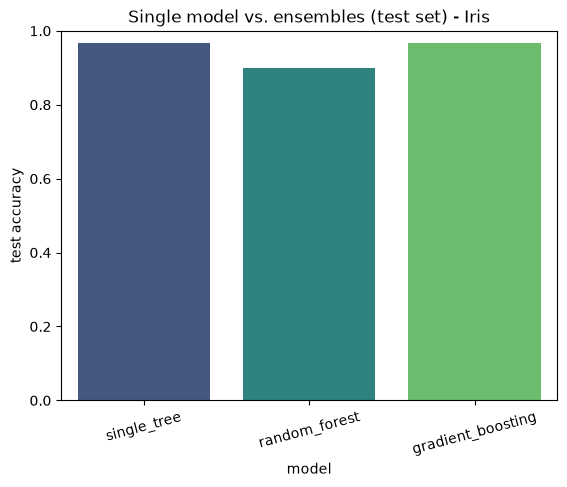

2026-08-02 21:15:31 | INFO | M05C | Best model: single_tree with test accuracy = 0.967


In [13]:
# Section 5. Compare

acc_single_tree: float = float(accuracy_score(y_test, modelA.predict(X_test)))
acc_random_forest: float = float(accuracy_score(y_test, modelB.predict(X_test)))
acc_gradient_boosting: float = float(accuracy_score(y_test, modelC.predict(X_test)))

LOG.info(f"  {'single_tree':18s} test accuracy = {acc_single_tree:.3f}")
LOG.info(f"  {'random_forest':18s} test accuracy = {acc_random_forest:.3f}")
LOG.info(f"  {'gradient_boosting':18s} test accuracy = {acc_gradient_boosting:.3f}")

scores: dict[str, float] = {
    "single_tree": acc_single_tree,
    "random_forest": acc_random_forest,
    "gradient_boosting": acc_gradient_boosting,
}

plt.figure()
x_keys = list(scores.keys())
y_values = list(scores.values())
sns.barplot(x=x_keys, y=y_values, hue=x_keys, palette="viridis", legend=False)
plt.ylim(0, 1)
plt.xlabel("model")
plt.ylabel("test accuracy")
plt.title("Single model vs. ensembles (test set) - Iris")
plt.xticks(rotation=15)
plt.show()

best: str = max(scores, key=scores.get)
LOG.info(f"Best model: {best} with test accuracy = {scores[best]:.3f}")

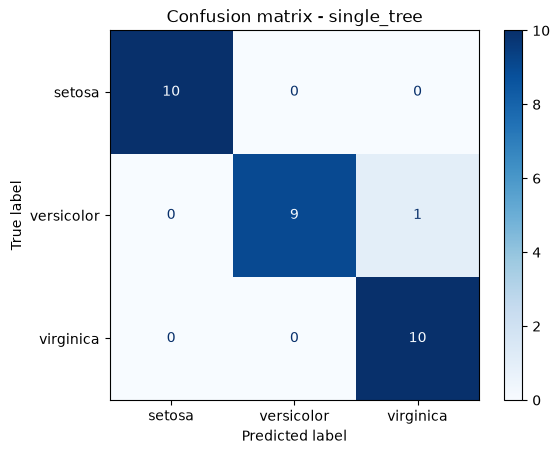

In [14]:
#  Section 5b. Confusion Matrix for the Best Model

best_model = {
    "single_tree": modelA,
    "random_forest": modelB,
    "gradient_boosting": modelC,
}[best]
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap="Blues")
plt.title(f"Confusion matrix - {best}")
plt.show()

### Interpretation

On the held-out test set, single_tree and gradient_boosting tied at 0.967 accuracy, while random_forest actually scored lower, at 0.900. The "best" label goes to single_tree only because it's first in the results dictionary and max() picks the first match on a tie - not because the tree truly beat gradient boosting.

Neither ensemble earned its extra complexity here. Iris is small, clean, and well-separated (only 30 test rows), so a shallow decision tree already captures nearly all the signal, leaving the ensembles nothing extra to improve on.


## Section 6. Which Features Did the Forest Rely On?

2026-08-02 21:15:31 | INFO | M05C | Random forest feature importances (high to low):
2026-08-02 21:15:31 | INFO | M05C |   petal_length         0.454
2026-08-02 21:15:31 | INFO | M05C |   petal_width          0.412
2026-08-02 21:15:31 | INFO | M05C |   sepal_length         0.116
2026-08-02 21:15:31 | INFO | M05C |   sepal_width          0.018


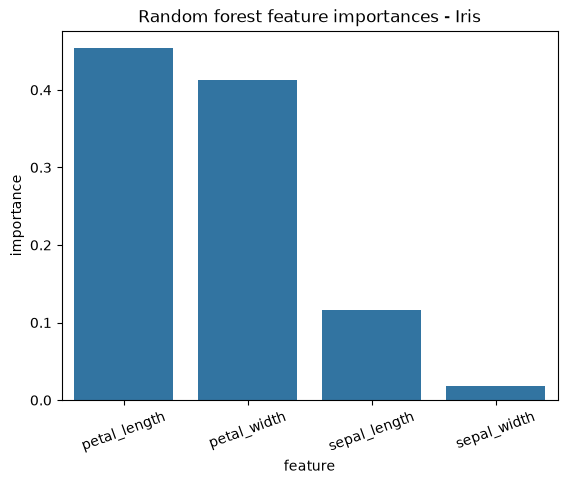

In [15]:
# Section 6. Feature Importances (Random Forest)

importances: np.ndarray = modelB.feature_importances_
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

plt.figure()
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]
sns.barplot(x=x_values, y=y_values)
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances - Iris")
plt.xticks(rotation=20)
plt.show()

## Section 7. Summary and Next Steps

In [16]:
# summary

LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (classification)")
LOG.info("Compared: single tree vs. random forest vs. gradient boosting")
LOG.info("========================")

2026-08-02 21:15:31 | INFO | M05C | ========================
2026-08-02 21:15:31 | INFO | M05C | SUMMARY
2026-08-02 21:15:31 | INFO | M05C | ========================
2026-08-02 21:15:31 | INFO | M05C | Dataset: iris   Target: species (classification)
2026-08-02 21:15:31 | INFO | M05C | Compared: single tree vs. random forest vs. gradient boosting
2026-08-02 21:15:31 | INFO | M05C | ========================


### Custom Narrative

- Did either ensemble beat the single tree? No, gradient boosting tied it exactly, and random forest scored worse (0.900 vs 0.967). On this dataset, more complexity did not mean more accuracy.
- Was any gain worth the extra cost? No gain occurred, so the simple tree is the easy choice here: same accuracy, far less training cost, and much easier to explain.
- Do the feature importances match expectations? Yes, the random forest leaned almost entirely on petal_length (0.454) and petal_width (0.412), with sepal_length (0.116) and sepal_width (0.018) barely mattering. This matches the well-known fact that petal measurements separate iris species far better than sepal measurements.


